In [1]:
%pip install numpy yaml2plot

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yaml2plot as y2p
import numpy as np

In [14]:
%load_ext autoreload
%autoreload 2
from test_all import *


test_op()
test_dc()
test_tran()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running ngspice in /foss/designs/simulations/tb_rms_det/test_op
Running ngspice in /foss/designs/simulations/tb_rms_det/test_dc
Running ngspice in /foss/designs/simulations/tb_rms_det/test_tran


In [10]:
op_file = "/foss/designs/simulations/tb_rms_det/test_op/op.log"

# Now passing a dictionary instead of a list!
my_devices = {
    "m.x2.xm1.m0": "Main 10uA Ref",
    "m.x1.xm5.m0": "Tail Sink 1",
    "m.x1.xm1.m0": "Skewed Quad Input",
    "m.x1.xm7.m0": "2I Subtracter",
    "m.x1.xm8.m0": "Even Current",
}

bias_data = get_op_bias(op_file, my_devices)

print("=== DC Operating Point (OP) Results ===")
print(f"{'Description':<20} | {'Device':<15} | {'Id (µA)':<8} | {'Vgs (V)':<7} | {'Vds (V)':<7}")
print("-" * 67)

for dev, data in bias_data.items():
    if "error" not in data:
        print(f"{data['desc']:<20} | {dev:<15} | {data['id']*1e6:>8.2f} | {data['vgs']:>7.3f} | {data['vds']:>7.3f}")
    else:
        print(f"{data['desc']:<20} | {dev:<15} | Not Found")

=== DC Operating Point (OP) Results ===
Description          | Device          | Id (µA)  | Vgs (V) | Vds (V)
-------------------------------------------------------------------
Main 10uA Ref        | m.x2.xm1.m0     |    10.00 |   1.019 |   1.019
Tail Sink 1          | m.x1.xm5.m0     |    40.39 |   1.019 |   1.388
Skewed Quad Input    | m.x1.xm1.m0     |    30.96 |   1.112 |   3.612
2I Subtracter        | m.x1.xm7.m0     |    18.89 |   1.237 |   0.232
Even Current         | m.x1.xm8.m0     |     0.00 |   0.232 |   0.232


  - i(@m.x1.xm8.m0[id])
  - v(i_ref)
  - v(net1)
  - v(net2)
  - i(v_inn)
  - i(v_inp)
  - i(v_vdd)
  - i(v_vss)
  - v(vdd)
  - v(vinn)
  - v(vinp)
  - v(vrms)
  - v(vss)
  - v(x1.net1)
  - v(x1.net2)


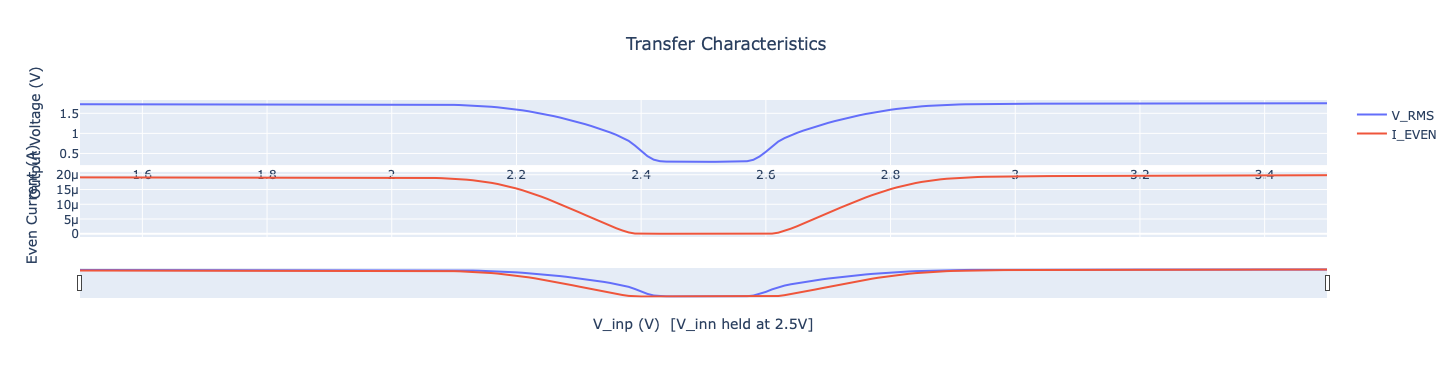

In [17]:
spice_file = "/foss/designs/simulations/tb_rms_det/test_dc/results.raw"

data = y2p.load_spice_raw(spice_file)

for signal, _ in data.items():
    print(f"  - {signal}")

spec = y2p.PlotSpec.from_yaml("""
title: "Transfer Characteristics"
x: 
  label: "V_inp (V)  [V_inn held at 2.5V]"
  signal: "v(vinp)"
y:
  - label: "Output Voltage (V)"
    signals:
      V_RMS: "v(vrms)"
  - label: "Even Current (A)"
    signals:
      I_EVEN: "i(@m.x1.xm8.m0[id])"
""")

fig_dc = y2p.plot(data, spec)

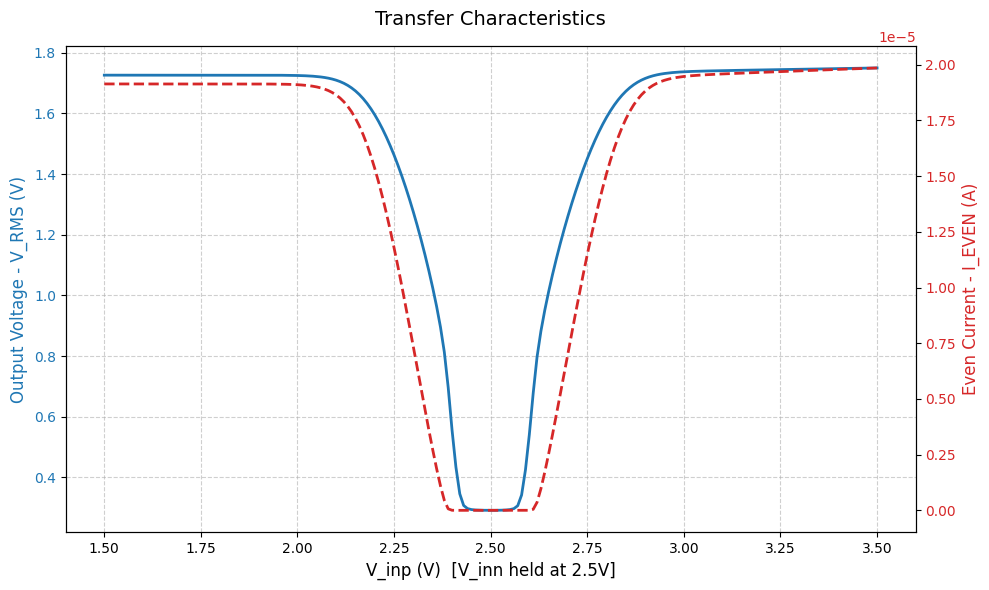

In [20]:
import yaml2plot as y2p
import matplotlib.pyplot as plt

# 1. Load the data
spice_file = "/foss/designs/simulations/tb_rms_det/test_dc/results.raw"
data = y2p.load_spice_raw(spice_file)

# Extract the arrays
x_sweep = data["v(vinp)"]
v_rms = data["v(vrms)"]
i_even = data["i(@m.x1.xm8.m0[id])"]

# 2. Setup the plot
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.title("Transfer CharacteristicsÍ", fontsize=14, pad=15)

# 3. Plot Left Axis (Voltage)
ax1.set_xlabel("V_inp (V)  [V_inn held at 2.5V]", fontsize=12)
ax1.set_ylabel("Output Voltage - V_RMS (V)", color="tab:blue", fontsize=12)
ax1.plot(x_sweep, v_rms, color="tab:blue", linewidth=2, label="V_RMS")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, linestyle="--", alpha=0.6)

# 4. Plot Right Axis (Current)
ax2 = ax1.twinx()  # This creates the shared X axis!
ax2.set_ylabel("Even Current - I_EVEN (A)", color="tab:red", fontsize=12)
ax2.plot(x_sweep, i_even, color="tab:red", linewidth=2, linestyle="--", label="I_EVEN")
ax2.tick_params(axis="y", labelcolor="tab:red")

# 5. Clean up and display
fig.tight_layout()
plt.show()

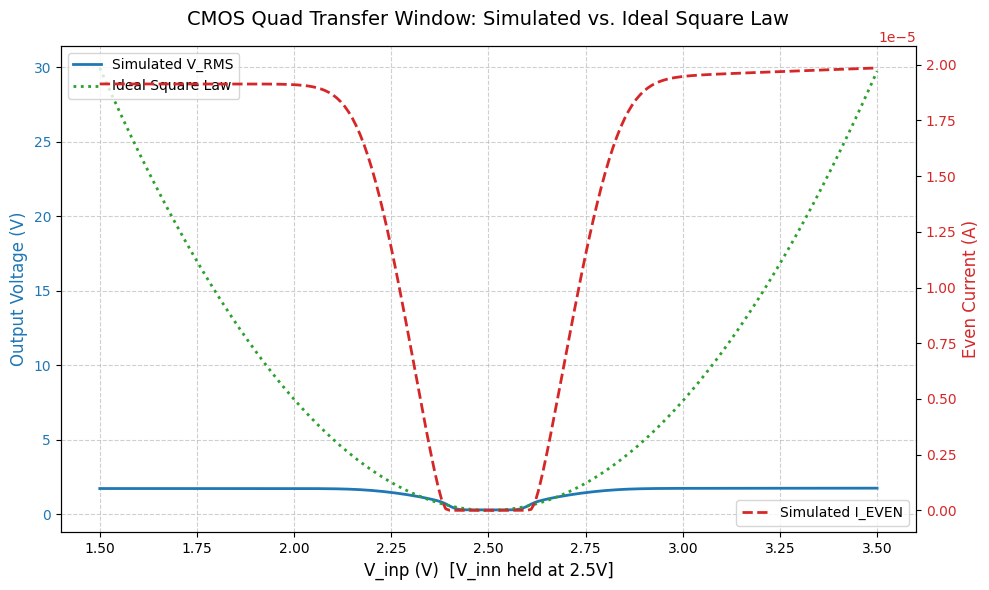

In [22]:
import yaml2plot as y2p
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
spice_file = "/foss/designs/simulations/tb_rms_det/test_dc/results.raw"
data = y2p.load_spice_raw(spice_file)

x_sweep = np.array(data["v(vinp)"])
v_rms = np.array(data["v(vrms)"])

# Updated syntax to match the parsed data keys
i_even = np.array(data["i(@m.x1.xm8.m0[id])"])

# 2. Calculate the Ideal Square Law Characteristic
# We fit a perfect 2nd-degree polynomial (parabola) to the central region 
# (e.g., +/- 0.2V from the 2.5V common mode) where the quad is most ideal.
center_mask = (x_sweep >= 2.3) & (x_sweep <= 2.7)
ideal_coeffs = np.polyfit(x_sweep[center_mask], v_rms[center_mask], 2)

# Generate the ideal curve across the entire x_sweep
v_rms_ideal = np.polyval(ideal_coeffs, x_sweep)

# 3. Setup the plot
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.title("CMOS Quad Transfer Window: Simulated vs. Ideal Square Law", fontsize=14, pad=15)

# 4. Plot Left Axis (Simulated & Ideal Voltage)
ax1.set_xlabel("V_inp (V)  [V_inn held at 2.5V]", fontsize=12)
ax1.set_ylabel("Output Voltage (V)", color="tab:blue", fontsize=12)

# Simulated Voltage (Solid Blue)
ax1.plot(x_sweep, v_rms, color="tab:blue", linewidth=2, label="Simulated V_RMS")
# Ideal Voltage (Dotted Green)
ax1.plot(x_sweep, v_rms_ideal, color="tab:green", linewidth=2, linestyle=":", label="Ideal Square Law")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(loc="upper left")

# 5. Plot Right Axis (Simulated Current)
ax2 = ax1.twinx()
ax2.set_ylabel("Even Current (A)", color="tab:red", fontsize=12)
ax2.plot(x_sweep, i_even, color="tab:red", linewidth=2, linestyle="--", label="Simulated I_EVEN")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.legend(loc="lower right")

# 6. Clean up and display
fig.tight_layout()
plt.show()

  - v(i_bias)
  - v(in)
  - v(in_n)
  - v(in_p)
  - v(out)
  - i(v_jumper_fb)
  - i(v_jumper_in)
  - i(v_src)
  - i(v_vdda)
  - i(v_vssa)
  - v(vdda)
  - v(vssa)
  - v(x1.net1)
  - v(x1.net2)


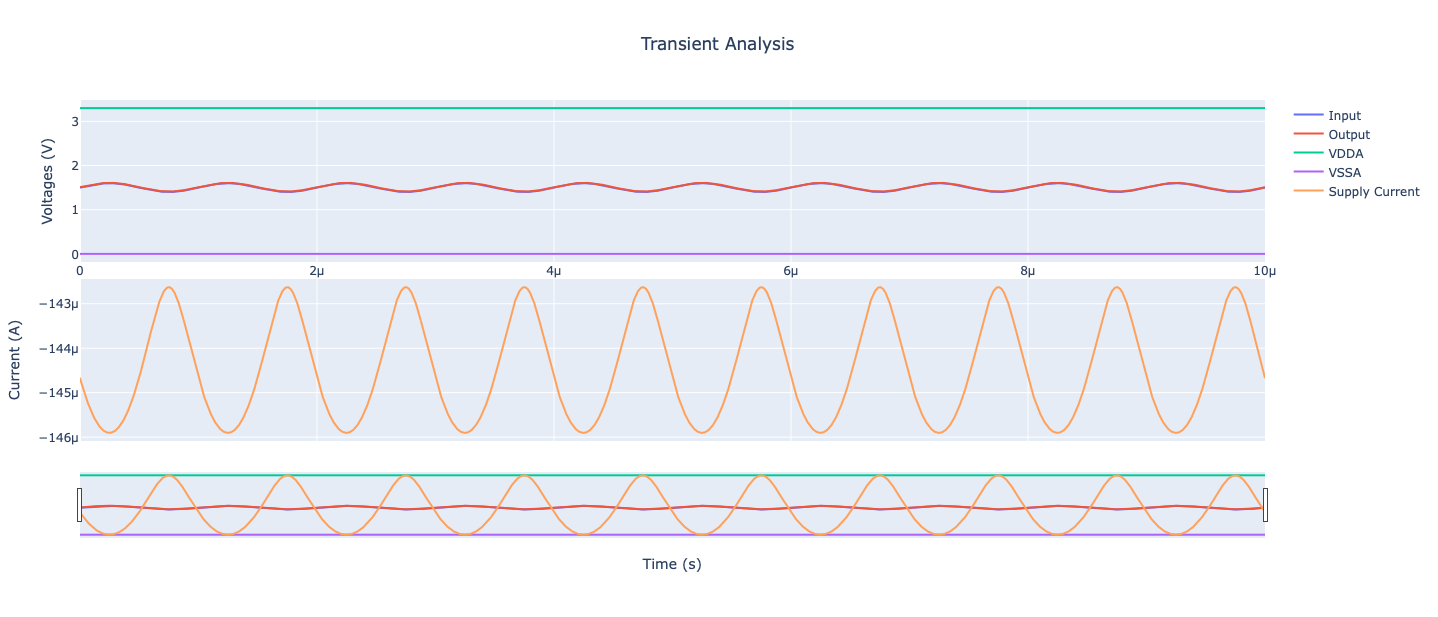

In [20]:

spice_file = "/foss/designs/simulations/tb_ota_5t/test_tran/results.raw"


data = y2p.load_spice_raw(spice_file)

for signal, _ in data.items():
    print(f"  - {signal}")

spec = y2p.PlotSpec.from_yaml("""
title: "Transient Analysis"

X:
  signal: "time"
  label: "Time (s)"

Y:
  - label: "Voltages (V)"
    signals:
      Input: "v(in)"
      Output: "v(out)"
      VDDA: "v(vdda)"
      VSSA: "v(vssa)"
      
  - label: "Current (A)"
    signals:
      Supply Current: "i(v_vdda)"

height: 600
show_rangeslider: true
""")

fig = y2p.plot(data, spec)

In [ ]:
spice_file = "/foss/designs/simulations/tb_ota_5t/test_ac/results.raw"


data = y2p.load_spice_raw(spice_file)

for signal, _ in data.items():
    print(f"  - {signal}")



data["tf_db"] = 20*np.log10(np.abs(data["v(out)"]))
data["tf_phase"] = np.angle(data["v(out)"])


# Now proceed with plotting using YAML configuration

spec = y2p.PlotSpec.from_yaml("""
title: "AC Analysis - Frequency Response"

X:
  signal: "frequency"
  label: "Frequency (Hz)"
  log_scale: true
                                    
Y:
  - label: "Magnitude (dB)"
    signals:
      Magnitude: "tf_db"
  - label: "Phase (deg)"
    signals:
      Phase: "tf_phase"
                            
height: 600
width: 800
show_rangeslider: true
""")

fig = y2p.plot(data, spec)

  - frequency
  - v(i_bias)
  - v(in)
  - v(in_n)
  - v(in_p)
  - v(out)
  - i(v_jumper_fb)
  - i(v_jumper_in)
  - i(v_src)
  - i(v_vdda)
  - i(v_vssa)
  - v(vdda)
  - v(vssa)
  - v(x1.net1)
  - v(x1.net2)
